<a href="https://colab.research.google.com/github/MAvRK7/Neural-Nets-Learning/blob/main/GPT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the GPT2 model from huggingface transformers library (pytorch code)

In [ ]:
from transformers import GPT2LMHeadModel

In [ ]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") #124M
sd_hf = model_hf.state_dict()

for k,v in sd_hf.items():
    print(k)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer.wte.weight
transformer.wpe.weight
transformer.h.0.ln_1.weight
transformer.h.0.ln_1.bias
transformer.h.0.attn.c_attn.weight
transformer.h.0.attn.c_attn.bias
transformer.h.0.attn.c_proj.weight
transformer.h.0.attn.c_proj.bias
transformer.h.0.ln_2.weight
transformer.h.0.ln_2.bias
transformer.h.0.mlp.c_fc.weight
transformer.h.0.mlp.c_fc.bias
transformer.h.0.mlp.c_proj.weight
transformer.h.0.mlp.c_proj.bias
transformer.h.1.ln_1.weight
transformer.h.1.ln_1.bias
transformer.h.1.attn.c_attn.weight
transformer.h.1.attn.c_attn.bias
transformer.h.1.attn.c_proj.weight
transformer.h.1.attn.c_proj.bias
transformer.h.1.ln_2.weight
transformer.h.1.ln_2.bias
transformer.h.1.mlp.c_fc.weight
transformer.h.1.mlp.c_fc.bias
transformer.h.1.mlp.c_proj.weight
transformer.h.1.mlp.c_proj.bias
transformer.h.2.ln_1.weight
transformer.h.2.ln_1.bias
transformer.h.2.attn.c_attn.weight
transformer.h.2.attn.c_attn.bias
transformer.h.2.attn.c_proj.weight
transformer.h.2.attn.c_proj.bias
transformer.h.2.ln_2

In [ ]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

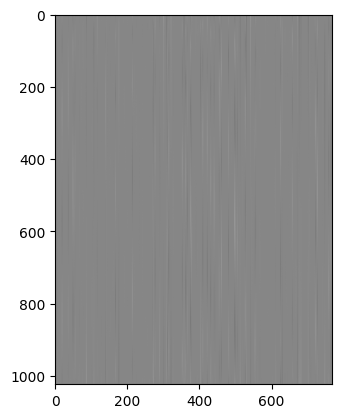

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

#lets plot the pos emb
plt.imshow(sd_hf["transformer.wpe.weight"], cmap="grey")

Every row in this is a fixed absolute position in range(0, 1024)

each row is the rep of that position. So it has structure

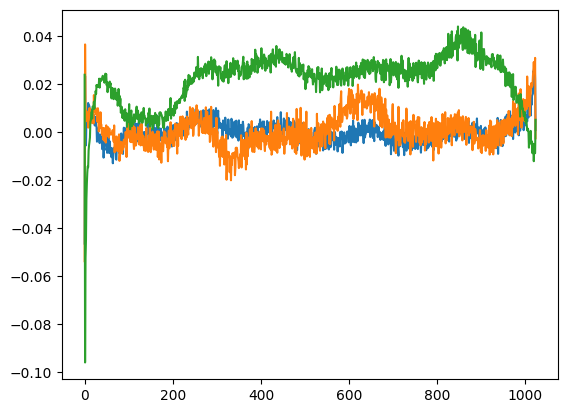

In [ ]:
plt.plot(sd_hf["transformer.wpe.weight"][:,150])
plt.plot(sd_hf["transformer.wpe.weight"][:,200])
plt.plot(sd_hf["transformer.wpe.weight"][:,250])

It has structure, not random, jagged: so can be trained more

In the original the pos emb was fixed to sinusoids and cosines of dif frequencies (fixed)

Here, they're trained- like any other params

one of its attentn weights

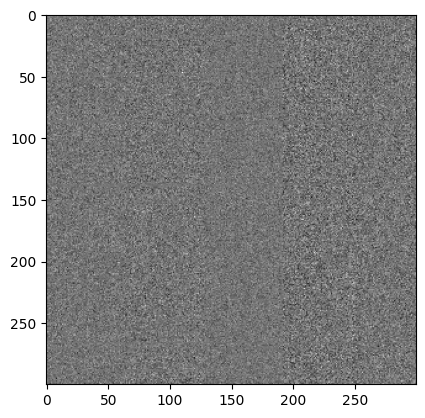

In [ ]:
plt.imshow(sd_hf["transformer.h.0.attn.c_attn.weight"][:300,:300], cmap="grey")

In [ ]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, I'm a language model. In my mind, I'm doing the same thing as you. All these different people are thinking about the same thing.\n\nI'm not talking about what the computer program does. I'm talking about what I'm thinking about. I'm thinking about what my body is thinking about. I'm thinking about what I'm making it. I'm thinking about what I'm making it. What my body is doing. I'm thinking about what my body is thinking about. What's my body doing? What's my body doing? What's my body doing?\n\nLet's talk about this, I'm not a computer programmer. I'm not a software developer. I'm not a computer programmer. I'm not a language model. I'm not a language model. My body is thinking about what I'm doing. What is my body doing? What's my body doing? What's my body doing?\n\nNow, I'm not saying that this is a good thing. But if you want to get better at programming, you can get better at writing. You can get better at being human. You can get

-----------

Writing the whole code

-----------

In [ ]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

In [ ]:
@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384
'''
we want to match

transformer.wte.weight
transformer.wpe.weight
transformer.h.0.ln_1.weight
transformer.h.0.ln_1.bias
transformer.h.0.attn.c_attn.weight
transformer.h.0.attn.c_attn.bias
transformer.h.0.attn.c_proj.weight
'''

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

#THIS WAS THE SKELETON

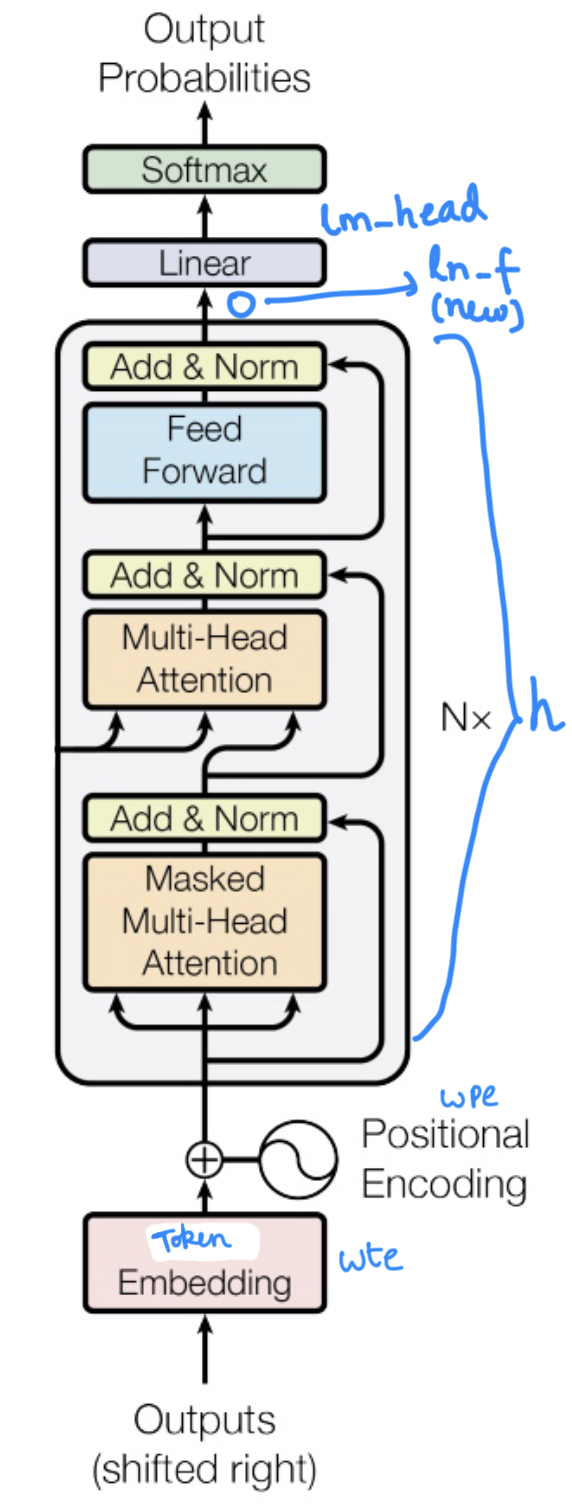

Fig 1: Transformer arch

###Transformer block

In [ ]:
# going into the block (h)
#---------------------------------------------------------------------
class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln1 = nn.LayerNorm(config.n_embd)
    self.ln2 = CausalSelfAttention(config)
    self.ln2 = nn.LayerNorm(onfig.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x
#---------------------------------------------------------------------

@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384


class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

###MLP block

In [ ]:
# going into the MLP block
#---------------------------------------------------------------------

class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

#---------------------------------------------------------------------
class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln1 = nn.LayerNorm(config.n_embd)
    self.ln2 = CausalSelfAttention(config)
    self.ln2 = nn.LayerNorm(onfig.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384


class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

###Attention (multi head) block

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

#---------------------------------------------------------------------
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y
#---------------------------------------------------------------------

class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    #-----------------to generate----------------

    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and posisition embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss
    #-----------------to generate----------------

  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

#-------------------------------------------------------------------------------------------------------
model = GPT.from_pretrained('gpt2')
print("Didnt crash")


loading weights from pretrained gpt: gpt2
Didnt crash


###Make it generate

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

  #-----------------to generate----------------

  def forward(self, idx, targets=None):
      # idx is of shape (B, T)
      B, T = idx.size()
      assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
      # forward the token and posisition embeddings
      pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
      pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
      tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
      x = tok_emb + pos_emb
      # forward the blocks of the transformer
      for block in self.transformer.h:
          x = block(x)
      # forward the final layernorm and the classifier
      x = self.transformer.ln_f(x)
      logits = self.lm_head(x) # (B, T, vocab_size)
      loss = None
      if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
      return logits, loss
  #-----------------to generate----------------

  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

#-------------------------------------------------GEN------------------------------------------------------

num_return_sequences = 5
max_length = 30

model = GPT.from_pretrained('gpt2')
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

import tiktoken
# Initialize the encoder
enc = tiktoken.get_encoding("gpt2")
# Encode the input text
tokens = enc.encode("Hello, Im a language Model")
# Convert to a tensor and repeat for num_return_sequences
tokens = torch.tensor(tokens, dtype=torch.long)  # (3,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)  # (5, 8)
# Move to the appropriate device
x = tokens.to(device)


# generate! right now x is (B,T) where B = 5, T = 8
# set the seed to 42
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    # topk_probs here becomes (5,50), topk_indices is (5,50)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)

loading weights from pretrained gpt: gpt2
Hello, Im a language Modeler. A language modeler.

I made it simple, a simple programming model.

That's the
> Hello, Im a language Modeler. A language modeler.

I made it simple, a simple programming model.

That's the
Hello, Im a language Model of all these models. I'm currently looking to re-use some of these (and several others, see this post
> Hello, Im a language Model of all these models. I'm currently looking to re-use some of these (and several others, see this post
Hello, Im a language Modeler and this is what you are doing. I am making models for you and I will keep building this, I hope
> Hello, Im a language Modeler and this is what you are doing. I am making models for you and I will keep building this, I hope
Hello, Im a language Modeler that is working with some of the most innovative programming paradigms including C, Java and Go. I wanted to
> Hello, Im a language Modeler that is working with some of the most innovative progra

Auto detect the device

In [ ]:
#----------------------------------------------------------------------------------------
# attempt to autodetect device
device = "cpu"
if torch.cuda.is_available():
  device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): ##apple silicon
  device = "mps"
print(f"using device: {device}")

#-----------------------------------------------------------------------------------------

num_return_sequences = 5
max_length = 30

model = GPT.from_pretrained('gpt2')
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#get a data batch
import tiktoken
# Initialize the encoder
enc = tiktoken.get_encoding("gpt2")
# Encode the input text
tokens = enc.encode("Hello, Im a language Model")
# Convert to a tensor and repeat for num_return_sequences
tokens = torch.tensor(tokens, dtype=torch.long)  # (3,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)  # (5, 8)
# Move to the appropriate device
x = tokens.to(device)


# generate! right now x is (B,T) where B = 5, T = 8
# set the seed to 42
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    # topk_probs here becomes (5,50), topk_indices is (5,50)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)

using device: cpu
loading weights from pretrained gpt: gpt2
> Hello, Im a language Modeler. A language modeler.

I made it simple, a simple programming model.

That's the
> Hello, Im a language Model of all these models. I'm currently looking to re-use some of these (and several others, see this post
> Hello, Im a language Modeler and this is what you are doing. I am making models for you and I will keep building this, I hope
> Hello, Im a language Modeler that is working with some of the most innovative programming paradigms including C, Java and Go. I wanted to
> Hello, Im a language Model that represents a single set of values (it is an empty set, so I just set 2 values to a 3-


## Training the model
not just loading weights

In [ ]:
# dataset
# RUN
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
data = text[:1000] #first 1000 chars
print(data)

--2026-01-06 02:58:55--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.03s   

2026-01-06 02:58:56 (31.8 MB/s) - ‘input.txt’ saved [1115394/1115394]

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it b

In [ ]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [ ]:
# tokenize it
#RUN
import tiktoken
enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [ ]:
words= enc.decode(tokens[:24])
print(words)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.


We want to feed these tokens into the transformer

We want to re-arrange these tokens into "idx" variable. Not a single very long seq,

An entire batch, where each seq is T tokens (T < max_seq_len)

T long sequences, B independant egs

In [ ]:
import torch
# get torch and make it a tensor object (buffer )
buf = torch.tensor(tokens[:24])
# view it
x = buf.view(4,6)
print(x)
# BUT 13 does NOT have the target (its not loaded)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])


WITH targets (y)

In [ ]:
import torch
buf = torch.tensor(tokens[:24+ 1]) #the ground truth for the last(13)
# inputs
x = buf[:-1].view(4,6) #everything upto the last token
#targets
y = buf[1:].view(4,6) #skip the first
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


## Implementing this in the full code

In [ ]:
# TRIAL RUN --------Debug only-------
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)



  def forward(self, idx, targets=None):
      # idx is of shape (B, T)
      B, T = idx.size()
      assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
      # forward the token and posisition embeddings
      pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
      pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
      tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
      x = tok_emb + pos_emb
      # forward the blocks of the transformer
      for block in self.transformer.h:
          x = block(x)
      # forward the final layernorm and the classifier
      x = self.transformer.ln_f(x)
      logits = self.lm_head(x) # (B, T, vocab_size)
      loss = None
      if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
      return logits, loss


  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model



device = "cpu"
if torch.cuda.is_available():
  device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): ##apple silicon
  device = "mps"
print(f"using device: {device}")
device = "cpu" #OVERRIDE

#get a data batch
import tiktoken
# Initialize the encoder
enc = tiktoken.get_encoding("gpt2")

#----------------------DEBUGGING ONLY trial run-----------------------------------
with open("input.txt","r") as f:
  text = f.read()
text = text[:1000]
# Encode the input text
tokens = enc.encode(text)
B,T = 4, 32
buf = torch.tensor(tokens[:B*T + 1]) #the ground truth for the last(13)
# inputs
x = buf[:-1].view(B,T) #everything upto the last token
#targets
y = buf[1:].view(B,T) #skip the first

#get logits
model = GPT(GPTConfig())
model.to(device)
logits,loss = model(x)

print(logits.shape)
import sys; sys.exit(0)# ---------STOP AFTER THIS----------------------------------------------------------------------

# NOT ANYMORE model = GPT.from_pretrained('gpt2')
model.eval()
# NOT ANYMORE device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
num_return_sequences = 5
max_length = 30


# generate! right now x is (B,T) where B = 5, T = 8
# set the seed to 42
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    # topk_probs here becomes (5,50), topk_indices is (5,50)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)


using device: cpu
torch.Size([4, 32, 50257])


SystemExit: 0

Now that the shape of logits is ([4, 32, 50257])

We must move to calculate loss, do backward and optimize and all

##Calculating LOSS

In [ ]:
# TRIAL RUN --------Debug only-------
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)



  def forward(self, idx, targets=None):
      # idx is of shape (B, T)
      B, T = idx.size()
      assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
      # forward the token and posisition embeddings
      pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
      pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
      tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
      x = tok_emb + pos_emb
      # forward the blocks of the transformer
      for block in self.transformer.h:
          x = block(x)
      # forward the final layernorm and the classifier
      x = self.transformer.ln_f(x)
      logits = self.lm_head(x) # (B, T, vocab_size)
      loss = None
      if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
          # basically F.cross_entropy doesnt like MULTI dim inputs, cant take (B, T, vocab_size)
          # so flatten (B, T, vocab_size) 3D -> 2D: b*t, vocab_size. Flatten tagets also 2D-> 1D (B*T)
      return logits, loss


  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model



device = "cpu"
if torch.cuda.is_available():
  device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): ##apple silicon
  device = "mps"
print(f"using device: {device}")
device = "cpu" #OVERRIDE

#get a data batch
import tiktoken
# Initialize the encoder
enc = tiktoken.get_encoding("gpt2")

#----------------------DEBUGGING ONLY trial run-----------------------------------
with open("input.txt","r") as f:
  text = f.read()
text = text[:1000]
# Encode the input text
tokens = enc.encode(text)
B,T = 4, 32
buf = torch.tensor(tokens[:B*T + 1]) #the ground truth for the last(13)
# inputs
x = buf[:-1].view(B,T) #everything upto the last token
#targets
y = buf[1:].view(B,T) #skip the first

#get logits
model = GPT(GPTConfig())
model.to(device)
logits,loss = model(x,y)

print(loss) #LOSS SHAPE---------------------------LOSS-------------------------
import sys; sys.exit(0)# ---------STOP AFTER THIS----------------------------------------------------------------------

# NOT ANYMORE model = GPT.from_pretrained('gpt2')
model.eval()
# NOT ANYMORE device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
num_return_sequences = 5
max_length = 30


# generate! right now x is (B,T) where B = 5, T = 8
# set the seed to 42
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    # topk_probs here becomes (5,50), topk_indices is (5,50)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)


using device: cpu
tensor(11.0965, grad_fn=<NllLossBackward0>)


SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


So the loss is the tensor of 1 element: 11

reasonable starting point: at init every vocab element must be uniformly probable

1/50257 = 0.00001989772569

-ln(1/50257) = 10.8249051197

so 11 is no wayy off

so prob dist is roughly diffused => good starting point

1. loss.backward()
2. calc grads
3. optimize

In [ ]:
# TRIAL RUN --------Debug only-------
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)



  def forward(self, idx, targets=None):
      # idx is of shape (B, T)
      B, T = idx.size()
      assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
      # forward the token and posisition embeddings
      pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
      pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
      tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
      x = tok_emb + pos_emb
      # forward the blocks of the transformer
      for block in self.transformer.h:
          x = block(x)
      # forward the final layernorm and the classifier
      x = self.transformer.ln_f(x)
      logits = self.lm_head(x) # (B, T, vocab_size)
      loss = None
      if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
          # basically F.cross_entropy doesnt like MULTI dim inputs, cant take (B, T, vocab_size)
          # so flatten (B, T, vocab_size) 3D -> 2D: b*t, vocab_size. Flatten tagets also 2D-> 1D (B*T)
      return logits, loss


  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model



device = "cpu"
if torch.cuda.is_available():
  device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): ##apple silicon
  device = "mps"
print(f"using device: {device}")
device = "cpu" #OVERRIDE

#get a data batch
import tiktoken
# Initialize the encoder
enc = tiktoken.get_encoding("gpt2")


with open("input.txt","r") as f:
  text = f.read()
text = text[:1000]
# Encode the input text
tokens = enc.encode(text)
B,T = 4, 32
buf = torch.tensor(tokens[:B*T + 1]) #the ground truth for the last(13)
# inputs
x = buf[:-1].view(B,T) #everything upto the last token
#targets
y = buf[1:].view(B,T) #skip the first

#get logits
model = GPT(GPTConfig())
model.to(device)
# logits,loss = model(x,y)


# Optimize! #----------------------------------------------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
for i in range(50):
  optimizer.zero_grad() # ⭐ ⭐ ⭐ Dont forget to make it 0
  logits,loss = model(x,y)
  loss.backward()
  optimizer.step() # to update parameters and decrease the loss
  print(f"step{i}, loss: {loss.item()}") #.item() as loss is a tensor with a single element, .item() will convert that to a single float
  # float will live on the CPU
  # loss usually lives in the GPU, .item() will make torch ship it back to the CPU mem and conv to a float that we can print
# print(loss) #LOSS SHAPE---------------------------LOSS-------------------------


import sys; sys.exit(0)# ---------STOP AFTER THIS----------------------------------------------------------------------

# NOT ANYMORE model = GPT.from_pretrained('gpt2')
model.eval()
# NOT ANYMORE device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
num_return_sequences = 5
max_length = 30


# generate! right now x is (B,T) where B = 5, T = 8
# set the seed to 42
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    # topk_probs here becomes (5,50), topk_indices is (5,50)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)


using device: cpu
step0, loss: 10.970142364501953
step1, loss: 6.646014213562012
step2, loss: 4.3816046714782715
step3, loss: 2.647681474685669
step4, loss: 1.502210021018982
step5, loss: 0.831534206867218
step6, loss: 0.456498920917511
step7, loss: 0.2592179477214813
step8, loss: 0.16278785467147827
step9, loss: 0.10587344318628311
step10, loss: 0.07123809307813644
step11, loss: 0.05332779511809349
step12, loss: 0.043152499943971634
step13, loss: 0.035376567393541336
step14, loss: 0.029710115864872932
step15, loss: 0.026066044345498085
step16, loss: 0.023280983790755272
step17, loss: 0.020580267533659935
step18, loss: 0.017955688759684563
step19, loss: 0.015651270747184753
step20, loss: 0.013767693191766739
step21, loss: 0.012269408442080021
step22, loss: 0.011065647937357426
step23, loss: 0.010063175112009048
step24, loss: 0.009193161502480507
step25, loss: 0.008418787270784378
step26, loss: 0.007727710995823145
step27, loss: 0.007118040695786476
step28, loss: 0.006588306277990341
st

SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


####Potential Bug

If we have multiple GPUs. We can get an error

RuntimeError: Expected all tensors to be on the same device,
but found at least two devices, cuda:0 (the first GPU) and cpu

In [ ]:
'''
So if we had a GPU

buf = torch.tensor(tokens[:B*T + 1]) #the ground truth for the last(13)
# inputs
x = buf[:-1].view(B,T) #everything upto the last token
#targets
y = buf[1:].view(B,T) #skip the first

#get logits
model = GPT(GPTConfig())
model.to(device)
'''

We moved model to the GPU but buf is still in the CPU

so:

buf.to(device)?
>>NO

Since buf is a tensor, we cant do a .to(device)

buf = buf.to(device)
>>YES

--------------------------------

So now that we have debugged and trained on a single batch, we need to make a data loader and always load a fresh batch

In [ ]:
# RUN
# FULL DATASET
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
data = text

# tokenize
import tiktoken
enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(data)


--2026-01-06 11:08:48--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.04s   

2026-01-06 11:08:48 (26.8 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [ ]:
# full RUN --------Debug only-------
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        #-------------------------A flag for residual scaling ---------------
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 #---------attach the residual scale flag---------

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    #----------------------------Weight sharing scheme----------------------------start

    '''Token emb weights (bottom) == lm_head weights (top)'''
    self.transformer.wte.weight = self.lm_head.weight

    #-----------------------------------------------------------------------------end

    #------------------------------------Init--------------------------------------start
    ''' At the end of the init for GPT module, we call .apply of nn.Module, It iterates all the sub modules of this module and
    applies _init_weights function to them.'''
    #init params
    self.apply(self._init_weights)

  # iterate all modules, if they're in nn.Linear module:
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      std=0.02
      #--------------------------Residual scaling------------------------------------start
      if hasattr(module, "NANOGPT_SCALE_INIT"): #if residual scaling flag
        std *= (2 * self.config.n_layer) ** -0.5 #scale it
        # we have attentn and MLP, thats why 2
        #-----------------------------------------------------------------------------end
      torch.nn.init.normal_(module.weight, mean=0.0, std=std) #make weights Normal dist, SD=0.02
      if module.bias is not None: #if theres a bias
        torch.nn.init.zeros_(module.bias) #make it 0
          # by default Bias is NOT 0, its init with a uniform
    elif isinstance(module, nn.Embedding): #if nn.Embedding
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02) #make emb also 0.02 only
    # The only other is nn.LayerNorm. torch by default sets the scale to 1, offset = 0 (thats what we want)

   #-----------------------------------------------------------------------------end

  def forward(self, idx, targets=None):
      # idx is of shape (B, T)
      B, T = idx.size()
      assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
      # forward the token and posisition embeddings
      pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
      pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
      tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
      x = tok_emb + pos_emb
      # forward the blocks of the transformer
      for block in self.transformer.h:
          x = block(x)
      # forward the final layernorm and the classifier
      x = self.transformer.ln_f(x)
      logits = self.lm_head(x) # (B, T, vocab_size)
      loss = None
      if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
          # basically F.cross_entropy doesnt like MULTI dim inputs, cant take (B, T, vocab_size)
          # so flatten (B, T, vocab_size) 3D -> 2D: b*t, vocab_size. Flatten tagets also 2D-> 1D (B*T)
      return logits, loss


  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

#-----------------------------Data Loader-----------------------------------------start

import tiktoken

class DataLoaderLite:
  def __init__(self, B, T):
    self.B = B
    self.T = T

    #at init load tokens from disk and store them in memory
    with open("input.txt","r") as f:
      text = f.read() #read the entire text file
    # Initialize the encoder
    enc = tiktoken.get_encoding("gpt2") #tokenize it
    self.tokens = torch.tensor(tokens) #track the tokens
    print(f"loaded {len(self.tokens)} tokens") #total tokens
    print(f"1 epoch = {len(self.tokens)//(B*T)} batches") # no. batches in a single epoch (how many unique batches before we loop back to begin.)

    #state
    self.current_position = 0 #start in pos 0
    # walk the document in batches of B * T, take B*T and always advance in B*T

  def next_batch(self):
    #get a data batch
    B, T = self.B, self.T
    buf = self.tokens[self.current_position:self.current_position+B*T + 1] # while fetching we're fetching from current pos to B*T+1
    x = buf[:-1].view(B,T) #everything upto the last token (inputs)
    y = buf[1:].view(B,T) #skip the first
    # advance the position in the tensor
    self.current_position += B*T # always advance in B*T
    # if loading the next batch would be out of bounds, reset
    if self.current_position + (B * T + 1) > len(self.tokens): # if we run out of data
      self.current_position = 0 #loop back to 0
    return x,y

#-------------------------------------------------------------------------------------end
#-----Auto detect device------
device = "cpu"
if torch.cuda.is_available():
  device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): #apple silicon
  device = "mps"
print(f"using device: {device}")

#------------------USE THE DATA LOADER-----------------------------------------start
train_loader = DataLoaderLite(B = 4, T = 32)
#---------------------------------------------end

#--------reproducability-------
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)
#------------------------------

#get logits
model = GPT(GPTConfig())
model.to(device)
# logits,loss = model(x,y)


# Optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
for i in range(50):
  #get x, y for the current batch
  x,y = train_loader.next_batch()
  x,y = x.to(device), y.to(device) #move TENSORs from CPU to device
  optimizer.zero_grad() # ⭐
  logits,loss = model(x,y)
  loss.backward()
  optimizer.step() # to update
  print(f"step{i}, loss: {loss.item()}") #.item()
  # loss usually lives in the GPU, .item() will make torch ship it back to the CPU mem and conv to a float that we can print


import sys; sys.exit(0)# ---------STOP AFTER THIS----------------------------------------------------------------------

model.eval()
num_return_sequences = 5
max_length = 30


# generate!
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)


using device: cpu
loaded 338025 tokens
1 epoch = 2640 batches
step0, loss: 10.960028648376465
step1, loss: 9.687705993652344
step2, loss: 9.082905769348145
step3, loss: 9.145987510681152
step4, loss: 8.626201629638672
step5, loss: 8.331700325012207
step6, loss: 8.897953033447266
step7, loss: 8.837982177734375
step8, loss: 8.116044998168945
step9, loss: 8.042160987854004
step10, loss: 8.380850791931152
step11, loss: 7.435606479644775
step12, loss: 7.8245649337768555
step13, loss: 7.458941459655762
step14, loss: 7.5318779945373535
step15, loss: 7.366678237915039
step16, loss: 7.436795711517334
step17, loss: 8.29356861114502
step18, loss: 7.202801704406738
step19, loss: 7.887033462524414
step20, loss: 7.5059332847595215
step21, loss: 7.822871208190918
step22, loss: 6.425384998321533
step23, loss: 6.877798557281494
step24, loss: 6.827328681945801
step25, loss: 6.701854705810547
step26, loss: 6.814749717712402
step27, loss: 7.621227264404297
step28, loss: 7.173998832702637
step29, loss: 6.9

SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


1115394 chars became 338025 tokens (OK 3:1 compression)





-------------
small BUG

In [ ]:
print(sd_hf["lm_head.weight"].shape) #lang model head AT THE TOP of the transformer
print(sd_hf["transformer.wte.weight"].shape) #tokem emb at the BOTTOM of the transformer

torch.Size([50257, 768])
torch.Size([50257, 768])


(refer to Fig. 1) So Token embedding and lm_head have the same shape (in huggingface)

In [ ]:
# further, every single element is identical
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [ ]:
# even the data-pointer is identical
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

133639313018835
133639313018835


The BUG: So these weights values are the same. This not same in our case, so we need to make it the same (efficiency)

Why?
> its big: 50257 * 768 is 40M params. 124M/40M = 30% of the params, Save it

Next up
###Initialization

Till now, we didnt care much about init, lets init properly

- When the init their weights, thet used an SD of 0.02 (normal dist).

- For bias, they init with 0

- Token emb is init with SD of 0.02, pos emb with SD: 0.01

0.02 is basically conistant with Javier Init

n_embd is 768, so 1/ sqrt(768) =  0.03

next up
###Residual Stream

In [ ]:
#example
# lets start with 768 zeros and then for 100 times we have a residual stream
x = torch.zeros(768)
print(f"before: {x.std()}")

n = 100
for i in range(n):
  x += torch.randn(768) # we add a normal dist, 0 mean, 1 SD
print(f"After: {x.std()}")


before: 0.0
After: 10.092613220214844


Scaling

In [ ]:
n=100
x = torch.zeros(768)
#BUT if we / sqrt(n) |where: n: number of residual layers
for i in range(n):
  x += n**-0.5 * torch.randn(768) # we add a normal dist, 0 mean, 1 SD
print(f"Scaled: {x.std()}")

Scaled: 0.9695279598236084


So Scaling is a way to control growth of acts inside a residual stream

n: number of residual layers

In [ ]:
x = torch.zeros(768)
for i in range(n):
  x += n**-0.5 * torch.randn(768)  # Add scaled noise

x *= n**-0.5  # Scale the sum to maintain standard deviation of 1
print(f"Scaled: {x.std()}")


Scaled: 0.10231520980596542


In [ ]:
logits.dtype

torch.float32

#GPUs and making it FASTER

##Ways of increasing efficiency

1.  Trade precision for performance

###1.1. FP32 -> FP16

Logits is a float32

> by default in torch, (for activations, params etc) everything in float32

 using a float representatn of 32 bits

 Deep learning can tolerate significant lower precions

 >> Precision ⬆ Performace ⬇️ Memory needed ⬆ idling ⬆ not good ⚠️

 GPUs support upto FP 64 (for sci calcs, but we dont need that much)

 Currently we're at FP 32 = 19.5 TFLOPS performance (at most)  [DEFAULT]

 i.e we're doing 19.5 Trillion floating point ops (*,+ etc) per sec

 If we can go down to FP16, we can 16x the performance

 In the pic, * means with sparcity (we dont use that). Look at it without the sparcity

 we can go down to FP 16,
 >we need flaoting point- cant do int for training. **Can use int for inference**

 Also moving numbers around- Memory is precious. With less precision, we can store more and utilize our resources more (less idling)

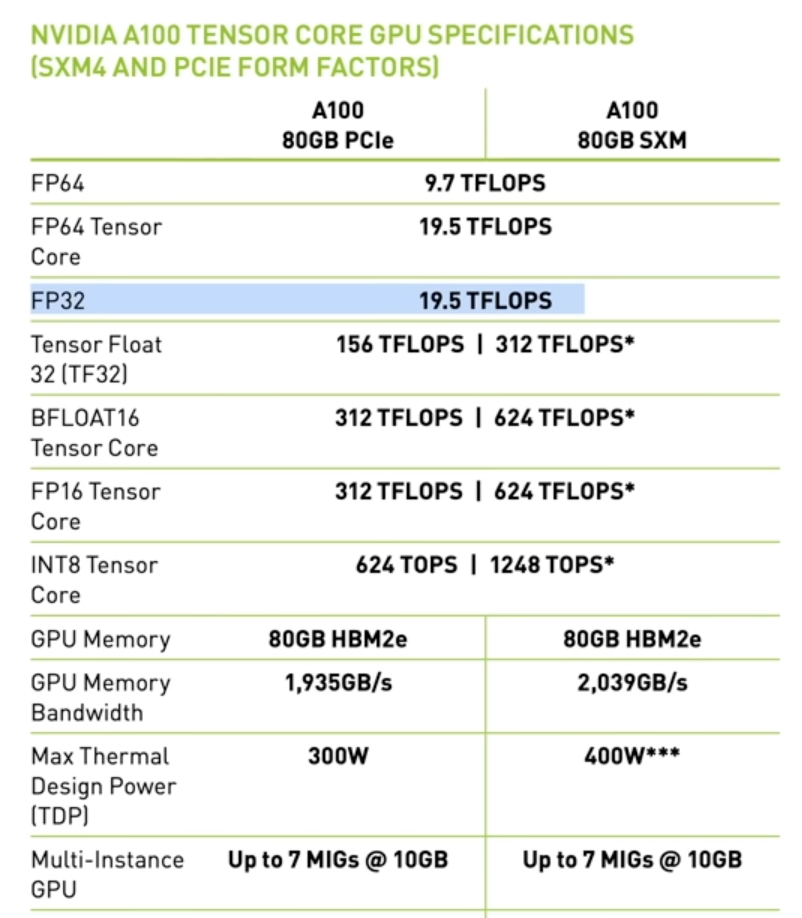

###Tensor cores

> an instruction in the a100 arch

A 4*4 matrix mul  

- there are many configs regarding precision of these matrices

ANYtime any op needs matrix mul, > they get broken to these instruction of 4*4 instruction

Most the heavy mat muls happen in the linear layers. There are few + in btw, GELU, residual, layerNorm etc. BUT mostly mat mul

Biggest here: 768 -> 50257

### 1.2. FP32 -> TF32

####Float 32

>1        10000000     10010000000000000000000

1[Sign].  8[exponent].  23[Mantissa]

####TF 32:

>1        10000000     1001000000

1 sign bit, 8 exponent bit, JUST **10** Mantissa bits [19 total]

so when we go from Float32 to TF32, internally 13 (32-19) bits just get dropped
> 8 x faster mat mul

Everything is FP32 but internally it gets chopped in TF32

---------------------------
Faster run

In [ ]:
# full RUN --------Debug only-------
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        #-------------------------A flag for residual scaling
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # ⚡------------flash attention----------⚡
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 #---------attach the residual scale flag---------

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length 😊
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token 😰
    n_layer: int = 12 # number of layers 😐
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension 😐

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    #----------------------------

    '''Token emb weights (bottom) == lm_head weights (top)'''
    self.transformer.wte.weight = self.lm_head.weight

    #--------------------------end

    #-----------Init---------start
    ''' At the end of the init for GPT module, we call .apply of nn.Module, It iterates all the sub modules of this module and
    applies _init_weights function to them.'''
    #init params
    self.apply(self._init_weights)

  # iterate all modules, if they're in nn.Linear module:
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      std=0.02
      #-------------Residual scaling--------------start
      if hasattr(module, "NANOGPT_SCALE_INIT"): #if residual scaling flag
        std *= (2 * self.config.n_layer) ** -0.5 #scale it
        # we have attentn and MLP, thats why 2
        #-------------------------------------------end
      torch.nn.init.normal_(module.weight, mean=0.0, std=std) #make weights Normal dist, SD=0.02
      if module.bias is not None: #if theres a bias
        torch.nn.init.zeros_(module.bias) #make it 0
          # by default Bias is NOT 0, its init with a uniform
    elif isinstance(module, nn.Embedding): #if nn.Embedding
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02) #make emb also 0.02 only
    # The only other is nn.LayerNorm. torch by default sets the scale to 1, offset = 0 (thats what we want)

   #-------------------------------------------------end

  def forward(self, idx, targets=None):
      # idx is of shape (B, T)
      B, T = idx.size()
      assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
      # forward the token and posisition embeddings
      pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
      pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
      tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
      x = tok_emb + pos_emb
      # forward the blocks of the transformer
      for block in self.transformer.h:
          x = block(x)
      # forward the final layernorm and the classifier
      x = self.transformer.ln_f(x)
      logits = self.lm_head(x) # (B, T, vocab_size)
      loss = None
      if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
          # basically F.cross_entropy doesnt like MULTI dim inputs, cant take (B, T, vocab_size)
          # so flatten (B, T, vocab_size) 3D -> 2D: b*t, vocab_size. Flatten tagets also 2D-> 1D (B*T)
      return logits, loss


  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params | 25:😰
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

#----------------Data Loader---------------start

import tiktoken

class DataLoaderLite:
  def __init__(self, B, T):
    self.B = B
    self.T = T

    #at init load tokens from disk and store them in memory
    with open("input.txt","r") as f:
      text = f.read() #read the entire text file
    # Initialize the encoder
    enc = tiktoken.get_encoding("gpt2") #tokenize it
    self.tokens = torch.tensor(tokens) #track the tokens
    print(f"loaded {len(self.tokens)} tokens") #total tokens
    print(f"1 epoch = {len(self.tokens)//(B*T)} batches") # no. batches in a single epoch (how many unique batches before we loop back to begin.)

    #state
    self.current_position = 0 #start in pos 0
    # walk the document in batches of B * T, take B*T and always advance in B*T

  def next_batch(self):
    #get a data batch
    B, T = self.B, self.T
    buf = self.tokens[self.current_position:self.current_position+B*T + 1] # while fetching we're fetching from current pos to B*T+1
    x = buf[:-1].view(B,T) #everything upto the last token (inputs)
    y = buf[1:].view(B,T) #skip the first
    # advance the position in the tensor
    self.current_position += B*T # always advance in B*T
    # if loading the next batch would be out of bounds, reset
    if self.current_position + (B * T + 1) > len(self.tokens): # if we run out of data
      self.current_position = 0 #loop back to 0
    return x,y

#-----------------------------------------end
import time

#-----Auto detect device------
device = "cpu"
if torch.cuda.is_available():
  device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): #apple silicon
  device = "mps"
print(f"using device: {device}")

#----------USE THE DATA LOADER-----------start
train_loader = DataLoaderLite(B = 8, T = 1024) #-------Bigger hyper params-----1024 is the actual max seq len of GPT2
# batch size: 8,16,32....
#----------------------------------------end

#------enable TF32--------
torch.set_float32_matmul_precision("high")
'''
- highest: default- everything is FP32
- high: matmul only TF32 (if available)
'''
#-------------------------

#--------reproducability-------
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)
#------------------------------

#get logits
model = GPT(GPTConfig(vocab_size=50304)) #------making vocab_size a nice number- adding fake tokens-----
model.to(device)
model = torch.compile(model)#-----torch.copile usage----

# Optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas = (0.9,0.95), eps=1e-8)
for i in range(50):
  t0 = time.time() #current time----
  #<<<<--------Optimization loop-------->>>>>
  #get x, y for the current batch
  x,y = train_loader.next_batch()
  x,y = x.to(device), y.to(device) #move TENSORs from CPU to device
  optimizer.zero_grad() # ⭐
  with torch.autocast(device_tye=device, dtype=torch.bfloat16): #---------Less memory usage----------
    logits, loss = model(x,y)
  loss.backward()
  '''we clip the global norm of the gradient at 1.0'''#-------
  norm = torch.nn.utils.clip_grad_norm(model.parameters(),1.0)
  optimizer.step() # to update
  #<<<<--------Optimization loop-------->>>>>
  torch.cuda.synchronize() #make sure GPU is done with its tasks, wait
  ''' CPU ships work to the GPU and what if we run through the optim but tasks are queued up > we'll get the wrong time,
  so torch.synchronize() makes it wait so that the queue is completed > correct time'''
  t1 = time.time()
  dt = (t1-t0) * 1000 #time difference in milliseconds
  print(f"step{i:4d} | loss: {loss.item():.6f} | norm: {norm:.4f} | dt: {dt*1000:.2f}ms | tok/sec: {tokens_per_sec:.2f}") #.item()
  # loss usually lives in the GPU, .item() will make torch ship it back to the CPU mem and conv to a float that we can print


import sys; sys.exit(0)# ---------STOP AFTER THIS----------------------------------------------------------------------

model.eval()
num_return_sequences = 5
max_length = 30


# generate!
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)


using device: cpu
loaded 338025 tokens
1 epoch = 41 batches


Now, its just 20 batches in a single epoch

If we have multiple GPUs. Torch will first fill up GPU 0

If RAM crashes, decrease batch size 16 ⬇️

> Going from FT32 -> TF32 = free speed (they said 8x we got 3x)

But we're still memory bound, we're moving these floats around (at the GPU memory bandwith's cost)

2. Move less stuff around- Memory efficiency

>Decrease stuff we're moving around

How?

>BFLOAT16

Maintain only 16 bits per float

Basics:

-Exponent: how much range
-Precision: how much prec

So the range is identical, but fewer posibilities within that range (less precision) - cropped mantissa

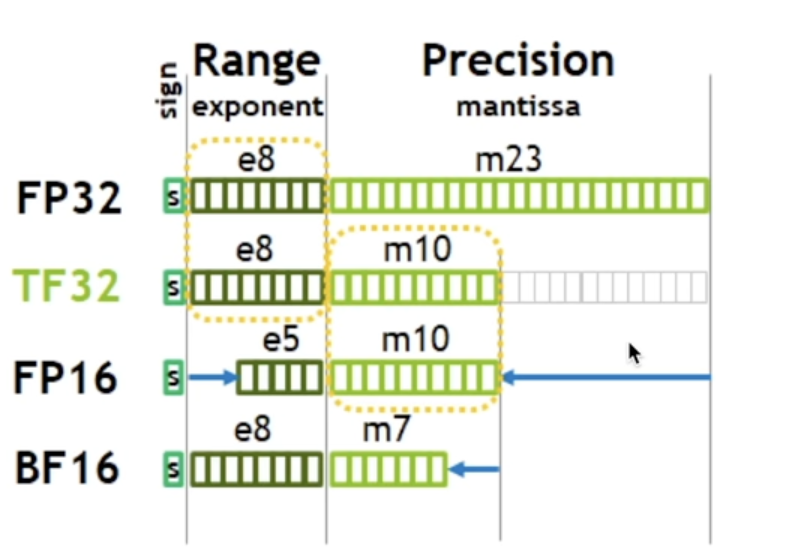

If we use torch.float16 (FP16), we reduce the range, so we have to use GRADIENT SCALERS and stuff (excess complication)

###2.1. Use torch.autocast

- So we use torch.autocast ONLY with the model (output and loss calc)
- leave backward and optimizer out

Remember:

With torch.autocast
- not everything becomes bfloat16
- eg logits is bfloat16 but transformer weights remain in FP32

Basically

- matmul like stuff becomes bfloat16
- softmax, layernorm, log stuff, loss func calcs remain in FP32

A *little* faster. But this is how much we can increase performance with dec precision

Now, we will start using the heavy weapons

###2.2. Use torch.compile

compilor for neural nets

> ⬆️ compilation time, but will make the code run faster⚡

went from 300ms -> 129 ms (2.3x improvement)

How does it make things faster?

torch.compile will analyze the entire thing and what ops we would like to use (and it knows what will exaclty happen) and will optimize the process (wont run strictly line by line like python does)

- less round trips between the GPU and the HBM (Higher Bandwidth Memory) [GPU's RAM]
- kernel fusion

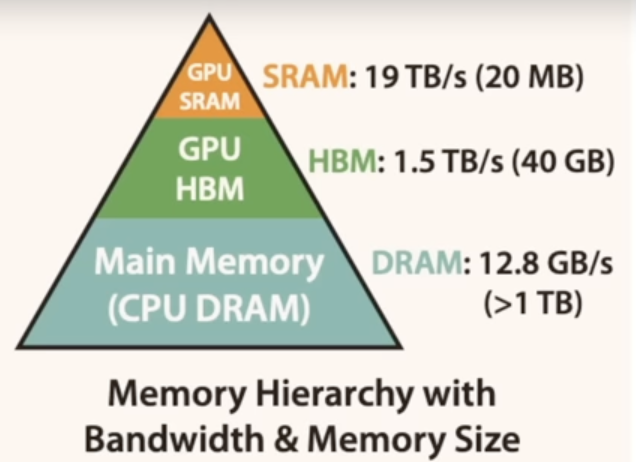

Speed capacity trade-off

> The faster the memory access is, the lesser is its capacity

But if we be smart and load most of the stuff in the GPU SRAM (using kernel fusion) - it'll be faster

###2.3. Use Flash Attention

In [ ]:
# replaces
'''
att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs
'''

torch.compile misses this , because its a different algo

###2.4. Use Nice numbers

###Nice and Ugly numbers

> Numbers with lots of 2x in them are nice 😊

eg: 32, 64, 256 😊

12, 6 😐

Ugly nos: 😰

13, 17 etc.(prime nos, odd)

Our vocab size is: 50257

Nearest 2x: **50304**

So we simply make our vocab size to 50,304. Even though we are wasting some memory and some more calcs- its faster. These "new fake tokens" are driven to 0 prob.

Why? block-tiles within GPUs are nice numbers. They do the nice part first and then the not nice part- can be inefficient- just pad inputs.

## 3. Algorithmic Changes to further ⬆️ performance

### 3.1. introduce betas, eps param on Adam

All these are from the GPT3 paper: https://arxiv.org/pdf/2005.14165

*"To train all versions of GPT-3, we use Adam with β1 = 0.9, β2 = 0.95, and ϵ= 10−8"*

### 3.2. Clip overall grad (grad norm)

"*we clip the global norm of the gradient at 1.0,*"

In [ ]:
'''
  norm = torch.nn.utils.clip_grad_norm(model.parameters(),1.0)
'''

'\n  norm = torch.nn.utils.clip_grad_norm(model.parameters(),1.0)\n'

it calculates the global norm -> every single gradient on all params-> square it -> sum it all up -> whole sq root

Norm of the param vector- its length basically. And we clip this lenght to 1.0

Why?

If we get unlucky, a lot of grad can come (high loss), this may shock the model, to avoid this, we clamp it

### 3.3. Learning rate decay (Cosine decay learning schedule with warmup)

*"and we use cosine decay for learning rate down to 10% of its value, over 260 billion tokens (after 260 billion tokens, training continues at 10% of the original learning rate)". There is a linear LR warmup over the first 375 million tokens.*

> warmup
> cosine-decay

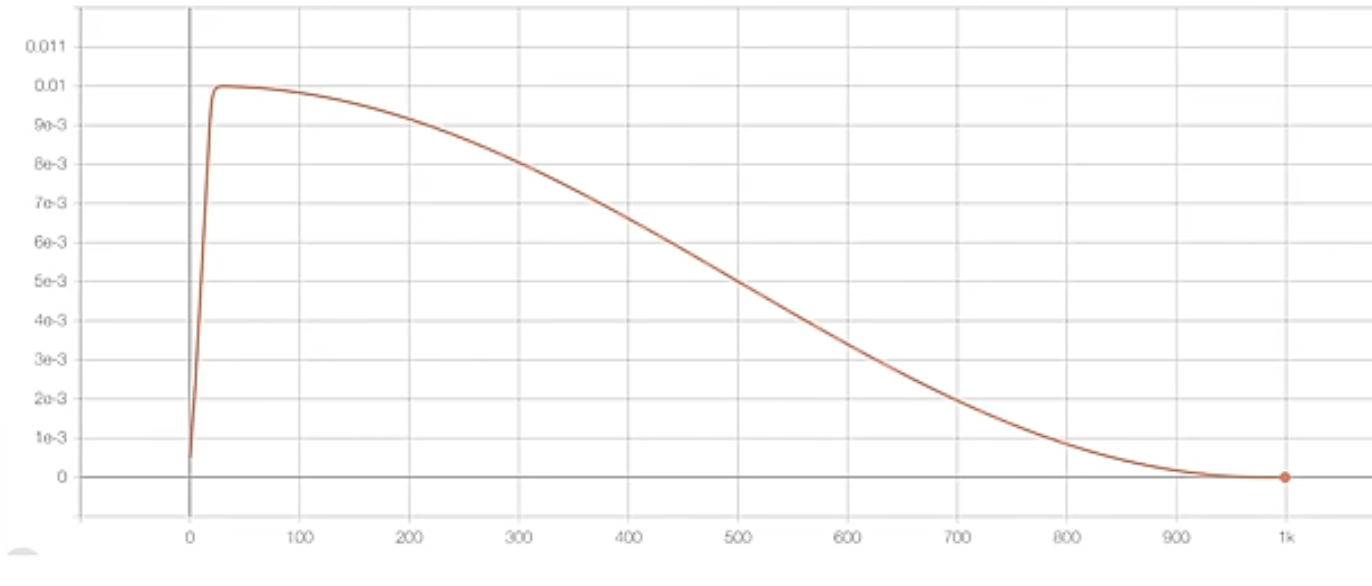

Starts from 0, linear increase till a certain point, then cosine decay and then, decays to a min point (0 here)

In [ ]:
# full RUN --------Debug only-------
import math
import os
import time
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        #-------------------------A flag for residual scaling
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # ⚡------------flash attention----------⚡
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu = nn.GELU(approximate="tanh")
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 #---------attach the residual scale flag---------

  def forward(self,x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

class Block(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config)
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config)

  def forward(self, x):
    x = x + self.attn(self.ln_1(x)) #pooling. communication
    x = x + self.mlp(self.ln_2(x)) #think indiv
    return x

#updated values
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length 😊
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token 😰
    n_layer: int = 12 # number of layers 😐
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension 😐

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    # main container is called transformer, so we make that a dict: a module that we can index into sub module using key (like a dict)
    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), #weights of token embeddings
        wpe = nn.Embedding(config.block_size, config.n_embd), #weights of pos emb
        # like h.0 (till h.11 as there as 12 hidden layers) we have a list
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = nn.LayerNorm(config.n_embd), #final layernorm
    ))
    # final classifier: lang model head: n_embd -> vocab_size
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    #----------------------------

    '''Token emb weights (bottom) == lm_head weights (top)'''
    self.transformer.wte.weight = self.lm_head.weight

    #--------------------------end

    #-----------Init---------start
    ''' At the end of the init for GPT module, we call .apply of nn.Module, It iterates all the sub modules of this module and
    applies _init_weights function to them.'''
    #init params
    self.apply(self._init_weights)

  # iterate all modules, if they're in nn.Linear module:
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      std=0.02
      #-------------Residual scaling--------------start
      if hasattr(module, "NANOGPT_SCALE_INIT"): #if residual scaling flag
        std *= (2 * self.config.n_layer) ** -0.5 #scale it
        # we have attentn and MLP, thats why 2
        #-------------------------------------------end
      torch.nn.init.normal_(module.weight, mean=0.0, std=std) #make weights Normal dist, SD=0.02
      if module.bias is not None: #if theres a bias
        torch.nn.init.zeros_(module.bias) #make it 0
          # by default Bias is NOT 0, its init with a uniform
    elif isinstance(module, nn.Embedding): #if nn.Embedding
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02) #make emb also 0.02 only
    # The only other is nn.LayerNorm. torch by default sets the scale to 1, offset = 0 (thats what we want)

   #-------------------------------------------------end

  def forward(self, idx, targets=None):
      # idx is of shape (B, T)
      B, T = idx.size()
      assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
      # forward the token and posisition embeddings
      pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
      pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
      tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
      x = tok_emb + pos_emb
      # forward the blocks of the transformer
      for block in self.transformer.h:
          x = block(x)
      # forward the final layernorm and the classifier
      x = self.transformer.ln_f(x)
      logits = self.lm_head(x) # (B, T, vocab_size)
      loss = None
      if targets is not None:
          loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
          # basically F.cross_entropy doesnt like MULTI dim inputs, cant take (B, T, vocab_size)
          # so flatten (B, T, vocab_size) 3D -> 2D: b*t, vocab_size. Flatten tagets also 2D-> 1D (B*T)
      return logits, loss


  #------import weights from hugging face------

  @classmethod
  def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params | 25:😰
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

#---------------------------NEW optimizer config class----------------------------start

def configure_optimizers(self, weight_decay, learning_rate, device_type):
        # start with all of the candidate parameters (that require grad)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        # print number of params we're decaying and not
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        if master_process:
            print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
            print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the 🔥fused🔥 version if it is available
        # because older versions didnt have this
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == "cuda" #if available and GPU is available
        if master_process:
            print(f"using fused AdamW: {use_fused}")
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
        return optimizer
#----------------------------------------------------------------------------------end

#----------------Data Loader---------------start

import tiktoken

class DataLoaderLite:
  def __init__(self, B, T, process_rank, num_processes): #---make it aware of multi process--it takes process_rank & num_processes⭐
    self.B = B
    self.T = T
    self.process_rank = process_rank
    self.num_processes = num_processes

    #at init load tokens from disk and store them in memory
    with open("input.txt","r") as f:
      text = f.read() #read the entire text file
    # Initialize the encoder
    enc = tiktoken.get_encoding("gpt2") #tokenize it
    self.tokens = torch.tensor(tokens) #track the tokens
    print(f"loaded {len(self.tokens)} tokens") #total tokens
    print(f"1 epoch = {len(self.tokens)//(B*T)} batches") # no. batches in a single epoch (how many unique batches before we loop back to begin.)

    #state
    self.current_position = self.B * self.T * self.process_rank #NOT 0 ANYMORE differentiate processes, put some gap (B*T) btw them⭐
    # process 0: starts at 0, process 1: B*T, process 2: starts at 2*B*T..etc
    # walk the document in batches of B * T, take B*T and always advance in B*T

  def next_batch(self):
    #get a data batch
    B, T = self.B, self.T
    buf = self.tokens[self.current_position:self.current_position+B*T + 1] # while fetching we're fetching from current pos to B*T+1
    x = buf[:-1].view(B,T) #everything upto the last token (inputs)
    y = buf[1:].view(B,T) #skip the first
    # advance the position in the tensor
    self.current_position += B * T * self.num_processes # DONT always advance in B*T, advance by what the whole chunk takes⭐
    # if loading the next batch would be out of bounds, reset
    if self.current_position + (B * T * self.num_processes + 1) > len(self.tokens): # if we run out of data
      self.current_position = self.B * self.T * self.process_rank # NOT loop back to 0⭐
    return x,y

# --------------------------------------DDP---------------------------------------start
# simple (non DDP single GPU launch):
# python <file_name> eg: python gpt2.py
# DDP launch (eg 8 GPUs)
# torchrun --standalone --nproc_per_module=8 gpt2.py

# run the training loop
from torch.distributed import init_process_group, destroy_process_group
#import DDP
from torch.nn.parallel import DistributedDataParallel as DDP
# distribution in torch (dist)
import torch.distributed as dist

# set up DDP (Dsitributed Data Parallel)
# use command "torchrun" - sets up env vars: 1. RANK 2. LOCAL_RANK 3. WORLD_SIZE
ddp = int(os.environ.get('RANK', -1)) != -1 # is this a ddp run?
if ddp:
    # use of DDP atm demands CUDA, we set the device appropriately according to rank
    assert torch.cuda.is_available(), "for now i think we need CUDA for DDP"
    init_process_group(backend='nccl')
    ddp_rank = int(os.environ['RANK']) #the GPU decides this
    ddp_local_rank = int(os.environ['LOCAL_RANK'])
    ddp_world_size = int(os.environ['WORLD_SIZE']) #8
    device = f'cuda:{ddp_local_rank}' #CUDA: says which GPU (0-7)
    torch.cuda.set_device(device)
    master_process = ddp_rank == 0 # this process will do logging, checkpointing etc.
else:
    # vanilla, non-DDP run
    ddp_rank = 0
    ddp_local_rank = 0
    ddp_world_size = 1
    master_process = True
    # attempt to autodetect device -----Auto detect device------
    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"
    print(f"using device: {device}")

# -----------------------------------------------------------------------------end

# Now 8 different compilors will read this code | | | | | | | |
# only dif: they have dif DDP rank

#-----------------------------------------end
import time

#--------reproducability-------
torch.manual_seed(1337)
if torch.cuda.is_available():
  torch.cuda.manual_seed(1337)
#------------------------------

#----------Gradient Accumulation-----------start
total_batch_size = 524288 #2**19 ~0.5M tokens but a nice number😊
B = 16 #micro batch size
T = 1024 # seq len
#---------Adding * ddp_world_size wherever necessary---------
assert total_batch_size % (B * T * ddp_world_size) == 0, "make sure total batch-size is divisible by B * T * ddp_world_size"
grad_accum_steps = total_batch_size \\ (B * T * ddp_world_size) # this should be 32 , as 32 = (2**19)/ (16*1024)
# since we want this to be printed only once and not 8 times, print only for master process
if master_process:
  print(f"total desired batch size: {total_batch_size}")
  print(f"=> calculated gradient accumulation steps: {grad_accum_steps}")

#----------Make data loader lite aware of multi processes---
# NOT ANYMORE train_loader = DataLoaderLite(B = , T = 1024)
# batch size: 8,16,32....
train_loader = DataLoaderLite(B = B, T = T, process_rank = ddp_rank, num_processes=ddp_world_size)
#------------------------------------------end


#------enable TF32--------
torch.set_float32_matmul_precision("high")
'''
- highest: default- everything is FP32
- high: matmul only TF32 (if available)
'''
#-------------------------

#create model
model = GPT(GPTConfig(vocab_size=50304)) #------nice number----- 8 models are created
model.to(device) #they all move
model = torch.compile(model)#-----torch.copile usage----8 identical compilations in ||
#--wrap model into the DDP container--
if ddp:
  model = DDP(model, device_ids=[ddp_local_rank])
raw_model = model.module if ddp else model # always contains the raw unwrapped model⭐

#------------------learning rate decay-----same with DDP⭐
max_lr = 6e-4
min_lr = max_lr * 0.1 #10% of max
warmup_steps = 10
max_steps = 50 #of optimizatn
def get_lr(it):
  # 1) Linear warmup for warmup_iters steps (Warmup region)
  if it < warmup_steps:
    return max_lr * (it+1) / warmup_steps
  # 2) if it > lr_decay_iters, return min learning rate (Region after Optimizatn)
  if it > max_steps:
    return min_lr
  # 3) in between, use cosine decay down to min learning rate (in between)
  decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
  assert 0 <= decay_ratio <= 1
  coeff = 0.5 * (0.1 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
  return min_lr + coeff * (max_lr - min_lr)
  #----------------------------------------⭐

# Optimize!
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas = (0.9,0.95), eps=1e-8) NOT ANYMORE
optimizer = raw_model.config_optimizers(weight_decay=0.1, learning_rate=6e-4, device=device) #⭐not model anymore

for step in range(max_steps):
  t0 = time.time() #current time----
  optimizer.zero_grad() # ⭐ why loop it? just once
  loss_accum = 0.0
  #<<<<-----GRADIENT ACCUMULATION
  for micro_steps in range(grad_accum_steps):
    #get x, y for the current batch
    x,y = train_loader.next_batch()
    x,y = x.to(device), y.to(device) #move TENSORs from CPU to device (GPU)
    with torch.autocast(device_tye=device, dtype=torch.bfloat16): #-------Less memory usage--------
      logits, loss = model(x,y)
    # we have to scale the loss to account for gradient accumulation,
    # because the gradients just add on each successive backward().
    # addition of gradients corresponds to a SUM in the objective, but
    # instead of a SUM we want MEAN. Scale the loss here so it comes out right
    loss = loss / grad_accum_steps
    loss.accum += loss.detach()
    #---we dont want sync of DDP everytime (too wasteful), just in the last step (grad_accum_steps-1)
    if ddp:
       model.require_backward_grad_sync = (micro_step == grad_accum_steps-1)
    loss.backward()
  # printing----
  # it will just print the loss the master process loss that it saw on its process
  # we want it to print the loss on ALL processes and avg of that loss
  if ddp:
    dist.all_reduce(loss_accum, op=dist.ReduceOp.AVG)
  # loss_accum tensor exists on all ranks, all_reduce of AVG, when called, creates the avg of that and deposits that avg on all ranks
  # After this, all ranks will contain avg of loss_accum
  #-------global norm clipped
  norm = torch.nn.utils.clip_grad_norm(model.parameters(),1.0)
  #⭐--------------------determine and set the learning rate for this iteratn------------------------⭐
  lr = get_lr(step)
  for param_group in optimizer.param_groups:
    param_group["lr"]=lr
  optimizer.step() # to update
  #------>>>>>
  torch.cuda.synchronize() #make sure GPU is done with its tasks, wait
  ''' CPU ships work to the GPU and what if we run through the optim but tasks are queued up > we'll get the wrong time,
  so torch.synchronize() makes it wait so that the queue is completed > correct time'''
  t1 = time.time()
  dt = (t1-t0) * 1000 #time difference in milliseconds
  #------------
  tokens_processed = train_loader.B * train_loader.T * grad_accum_steps * ddp_world_size #⭐
  tokens_per_sec = tokens_processed/ dt
  #------------
  if master_process: #doesnt really matter, all processes will have the same loss avged up
    print(f"step{i:4d} | loss: {loss_accum.item():.6f} | lr {lr:.4e} | norm: {norm:.4f} | dt: {dt*1000:.2f}ms | tok/sec: {tokens_per_sec:.2f}") #.item()
  # loss usually lives in the GPU, .item() will make torch ship it back to the CPU mem and conv to a float that we can print

#---destroy the process group---
if ddp:
  destroy_process_group()

import sys; sys.exit(0)# ---------STOP AFTER THIS----------------------------------------------------------------------

model.eval()
num_return_sequences = 5
max_length = 30


# generate!
torch.manual_seed(42)
#torch.device.manual_seed(42)
while x.size(1) < max_length:
  #forward the model to get the logits
  with torch.no_grad():
    logits, _ = model(x) # (B,T,vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B,vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1) # (B,vocab_size)
    # do top k sampling of 50 (huggingface pipeline default)
    topk_probs, topk_indices = torch.topk(probs,50, dim=-1)
    #select a token from top-k probabilities
    ix = torch.multinomial(topk_probs,1) # (B,1)
    # gather the corresponding indices
    xcol = torch.gather(topk_indices, -1,ix) # (B,1)
    # append to sequence
    x = torch.cat((x,xcol), dim=1)

# print the generated text
for i in range(num_return_sequences):
  tokens = x[i, :max_length].tolist()
  decoded = enc.decode(tokens)
  print(">", decoded)


### 3.4 Dynamic Increment of batch-size

*"We also gradually increase the batch size linearly from a small value (32k tokens) to the full value over the first 4-12 billion tokens of training, depending on the model size."*

We're not implementing this, as its not an algo thing, more of a systems/speed improvement (but tough/ complex to implement)

initially, in the early optimizatn, mostly the learning is
> ignore tokens that dont come up in training set very often

very simple bisases

so grads from every example roughly look the same

> they just say "these tokens" appear, "these" dont

so why do batch sizes of millions?

> just do small batch sizes initially (32k) then increase

Later on in the optim, once all the simple stuff is learnt -> actual work starts

> grads are more de-correlated per example batch, use bigger batch

###3.5. Data sampling w/o replacement - exhaustive pool

*"Data are sampled without replacement during
training (until an epoch boundary is reached) to minimize overfitting"*

We're doing this (as part of the data loader). Once a chunk is taken for training, its not put back in the dataset until the next epoch

###3.6. Weight Decay (as part of optimizer)

*"All models use weight decay of 0.1 to provide a
small amount of regularization"*

By default, in AdamW the weight decay is 0.01

So, we create a new def in class GPT: def config_optimizers

Here we first separate into
* should be weight decayed: 124M (most of them)
   - weights that participate in mat mul

   - embeddings
* should NOT be weight decayed: 121k (few)
   - biases

   - 1 dim tensors

> Why decay weights?

sorta like regularization, force network to distribute weight across more channels. Dont make any one indiv weight WAY too large

####Fused

Also use the new AdamW optimizer's optimizatn if available (called fused)

its a lot ⚡ with fused (CUDA Only)

- instead of iterating in a for loop over all the param tensor and updating them LOT OF KERNELS LAUNCHED

- Fused: Fuse all those kernels into 1, single time, 1 call to kernel to update
---------------------------------------------------------------

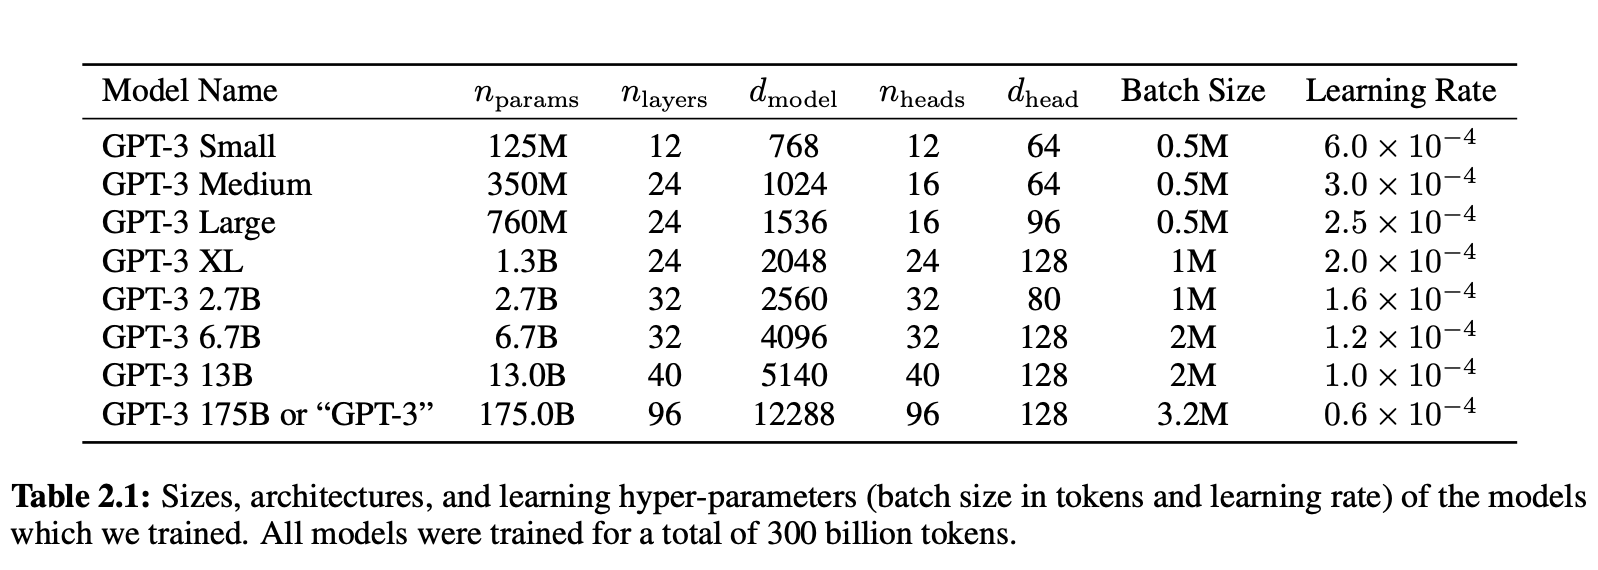

###Efficiency

Network size: ⬆️ learning date: ⬇️ Batch_size:⬆️

In our model batch_size (B=16) in GPT3 Small, batch_size is 0.5M tokens

in ours B=16, T=1024

So every row is 1024 tokens

In GPT3 small: 0.5M/1024 = 488. If we did that, GPU would explode

How do we put 0.5M tokens in the batch_size efficiently?

>>#### 1.1. Gradient Accumulation: higher batch_size sim

Simulate serially any batch_size

- we were doing: 16 * 1024 = 16,384, so we're doing 16,384 tokens per fwd/bckwd
- we're supposed to be doing 2**19, so 2^19 / 16,384 = 32

so 32 steps to accumulate

> 32 fwd/bckwds and then 1 update to simulate

For the update

In [ ]:
'''
  with torch.autocast(device_tye=device, dtype=torch.bfloat16): #-------Less memory usage--------
    logits, loss = model(x,y)
  loss.backward()

We must repeat this 32 times before doing everything else that follows
'''

But if we just do a loop:

* without gradient accumulation:

  - Mean loss: (L1 + L2 + L3 + L4)/4  | where: L= (y_actual - y_predicted)²

* With gradient accumulation:

  - Loss: L1 + L2 + L3 + L4 | the /4 is missing
  - so for every mini we must do /4
  - L1/4 + L2/4 + L3/4 + L4/4

So, we must fix it by "normalizing"

--------------------------------------------------------------
Heavy weapon

### 1.2. Distributed Data Parallel (DDP)

Enabling comm and colab over GPUs

Say, we have 8 GPUs, we launch 8 processes

> uses torchrun to run script

When we use this cmd, runs all 8 of the GPUs in parallel and it creates .env vars where each of these processes can look up and find out which one of the processes it is

If DDP is running -> check CUDA is available?

* eg. torch run will set
  1. **RANK**: each process (of the 8) will run the exact same process at the same ~time

      - DDP_RANK: only dif btw the process is that they have dif DDP rank
      - GPU 0: DDP_RANK: 0 | GPU 1: DDP_RANK: 1 etc.
      - we want them to run dif parts of data (not same). We use this rank to differentiate

  2. LOCAL_RANK: Only used in multi-node setting
     - We may have a single node with 8 GPUs
     - Its the rank of the GPU on a single node (eg 0-7)
  3. **WORLD_SIZE**: 8 (total no. of processes running - 8 GPUs 8 procs)

  We care about Rank and world_size

  >Which process (GPU) starts first and finish and who gets what: Arbitrary

  The system decides this

  Next up

  Data Loader Lite was un-aware of multi process setting.

  How to make data loader aware of the multi processes-
  
  * We dont want all processes to be loading the same data
  * every process gets its own chunk of data (different parts)


###DDP behaves identical in fwd pass (no change)
> in bckwd (simplest setting) once backward- avg and deposit over all GPUs (use: all reduce)

- in simplest setting: once the bckwd pass is over on each independent GPU- each indep GPU has the gradient for all the params
- once bckwd pass is over, DDP calls **all_reduce**
- **all_reduce** is basically an avg across all ranks of their gradients
- then it'll deposit that avg on every single rank (all ranks will end up with the avg on it)
- sync and communication: avg btw the gradients

DDP is more evolved than that

> dynamic (while still in proc) communication

- As backward pass is done thru the layers of the transformer.
- DDP can dispatch communicaton for the gradient WHILE the backward pass is still happening
- Theres overlap of the comminication of the gradients and theyre in sync
- more efficient

##Dataset

We have now outgrown the tiny shakespeare dataset. we're doing too many iters on that.

Real dataset

WebText2: Reddit with at least 3 karma

Common Crawl: random chunk of the internet (lots of noise)

Other open source datasets:
- Red Pyjama
  - slimmer version of that: Slim Pyjama

- FineWeb dataset 15T
  - FineWeb-Edu: educational content by hugging face🤗 5.4T tokens
    - Sample 10B (we'll use)

Code to download the dataset

In [ ]:
"""
FineWeb-Edu dataset (for srs pretraining)
https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu
Downloads and tokenizes the data and saves data shards to disk.
Run simply as:
$ python fineweb.py
Will save shards to the local directory "edu_fineweb10B".
"""

import os
import multiprocessing as mp
import numpy as np
import tiktoken
from datasets import load_dataset # pip install datasets
from tqdm import tqdm # pip install tqdm

# ------------------------------------------
local_dir = "edu_fineweb10B"
remote_name = "sample-10BT"
shard_size = int(1e8) # 100M tokens per shard, total of 100 shards

# create the cache the local directory if it doesn't exist yet
DATA_CACHE_DIR = os.path.join(os.path.dirname(__file__), local_dir)
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

# download the dataset
# 1. Download the dataset
fw = load_dataset("HuggingFaceFW/fineweb-edu", name=remote_name, split="train")

# init the tokenizer
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>'] # end of text token
def tokenize(doc):
    # tokenizes a single document and returns a numpy array of uint16 tokens
    # the starting token: eot
    tokens = [eot] # the special <|endoftext|> token delimits all documents
    tokens.extend(enc.encode_ordinary(doc["text"]))
    tokens_np = np.array(tokens)
    assert (0 <= tokens_np).all() and (tokens_np < 2**16).all(), "token dictionary too large for uint16"
    tokens_np_uint16 = tokens_np.astype(np.uint16)
    return tokens_np_uint16

def write_datafile(filename, tokens_np):
    np.save(filename, tokens_np)

# tokenize all documents and write output shards, each of shard_size tokens (last shard has remainder)
# 2. tokenize it
nprocs = max(1, os.cpu_count()//2)
with mp.Pool(nprocs) as pool:
    shard_index = 0
    # preallocate buffer to hold current shard
    all_tokens_np = np.empty((shard_size,), dtype=np.uint16)
    token_count = 0
    progress_bar = None
    for tokens in pool.imap(tokenize, fw, chunksize=16):

        # is there enough space in the current shard for the new tokens?
        if token_count + len(tokens) < shard_size:
            # simply append tokens to current shard
            all_tokens_np[token_count:token_count+len(tokens)] = tokens
            token_count += len(tokens)
            # update progress bar
            if progress_bar is None:
                progress_bar = tqdm(total=shard_size, unit="tokens", desc=f"Shard {shard_index}")
            progress_bar.update(len(tokens))
        else:
            # write the current shard and start a new one
            split = "val" if shard_index == 0 else "train"
            filename = os.path.join(DATA_CACHE_DIR, f"edufineweb_{split}_{shard_index:06d}")
            # split the document into whatever fits in this shard; the remainder goes to next one
            remainder = shard_size - token_count
            progress_bar.update(remainder)
            all_tokens_np[token_count:token_count+remainder] = tokens[:remainder]
            write_datafile(filename, all_tokens_np)
            shard_index += 1
            progress_bar = None
            # populate the next shard with the leftovers of the current doc
            all_tokens_np[0:len(tokens)-remainder] = tokens[remainder:]
            token_count = len(tokens)-remainder

    # write any remaining tokens as the last shard
    if token_count != 0:
        split = "val" if shard_index == 0 else "train"
        filename = os.path.join(DATA_CACHE_DIR, f"edufineweb_{split}_{shard_index:06d}")


Now, we can separate 10 mil parts of this and use that as the val data.

To supplement this evaluation, we can use HellaSwag

https://arxiv.org/pdf/1905.07830

Q. A woman is outside with a bucket and a dog. The dog is running
around trying to avoid a bath. She…

A. rinses the bucket off with soap and blow dry the dog’s head.

B. uses a hose to keep it from getting soapy.

C. gets the dog wet, then it runs away again.✅

D. gets into a bath tub with the dog.

Natural completion of the sentance. *Correct Context*

Also, the incorrect options are adversarially sourced. They're sentances generated by lang models

LLMs find it hard, but humans find it easy

Now, its been totally solved, used to be hard in ~2019

- slow improvement
- smooth
- early signal

we cant just feed the MCQs into the model, we feed it like this

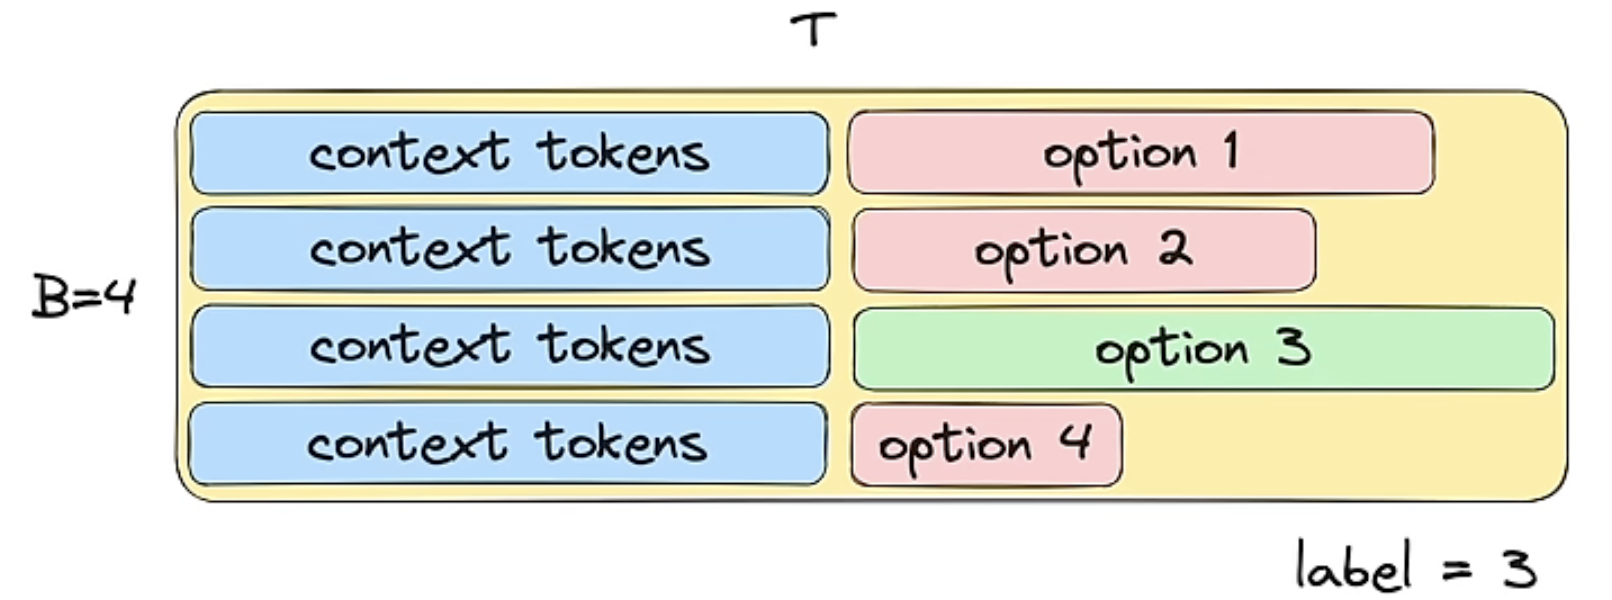

Small models are fed this block and they should assign probs to the highest

We see the cross_emtropy loss for each option (one at a time, the model doesnt see all the options at once)

Lower less-> highest prob

random chance for HellaSwag is 25%

Eleuther harness: infra for running evals on LLMs

More info and full code: https://github.com/karpathy/build-nanogpt/blob/master/train_gpt2.py

Going from this "documnet dreamer" to a conversational Assistant like ChatGPT

we have to do supervised fine-tuning (SFT)

Where the dataset is all User:.....; Assistant:.....

------------------------------------------------------------
Parameter count for GPT 2 124M (small):
* Vocab_size: 50,257 tokens | embed: 768

  50,257 * 768 = 38.6M

* ONE Transformer Layer (there are 12)
  - (Query, Key, Value, Output): 4 × (768 × 768) ≈ 2.36M
  -  Feed forward: 768 → 3072 → 768

     = 768×3072 + 3072×768 ≈ 4.72M
  - Biases + LayerNorm ≈ 0.02M
  - Total = (2.36 + 4.72 + 0.02) × 12 = (7.08) × 12 = 85M
  
* Output: tied to input so 0

TOTAL: 38.6M + 85M ≈ 124M


